In [2]:
import openmc
import os
cross_sections_path = "/home/linz/ondemand/openmc/nuclear_data/endfb-viii.0-hdf5/cross_sections.xml"
openmc.config["cross_sections"] = cross_sections_path

In [3]:
graphite=openmc.Material(name='graphite')
graphite.add_element('C',1.0,'ao')
graphite.set_density('g/cc',2.26)

#Hastelloy N / INOR-8 nominal material composition from
#ORNL-TM-4189
inor=openmc.Material(name='inor')
inor.add_element('Ni',0.72)
inor.add_element('Mo',0.16)
inor.add_element('Cr',0.07)
inor.add_element('Fe',0.05)
inor.set_density('g/cc',9)

# LiF,BeF2,UF4,ZrF4 [0.67,0.23,0.05,0.0079] mol % @ 33% enrichment 
molar_comp={'LiF':0.67,'BeF2':0.23, 'ZrF4':0.05, 'UF4':0.0079}
enrichment=0.3333
salt=openmc.Material(name='salt')
salt.add_element('F',molar_comp['LiF']*1/2+molar_comp['BeF2']*2/3+molar_comp['ZrF4']*4/5+molar_comp['UF4']*4/5,'ao')
salt.add_nuclide('Li7',molar_comp['LiF']*1/2,'ao')
salt.add_element('Be',molar_comp['BeF2']*1/3,'ao')
salt.add_element('Zr',molar_comp['ZrF4']*1/5,'ao')
salt.add_nuclide('U235',enrichment*molar_comp['UF4']*1/5,'ao')
salt.add_nuclide('U238',(1-enrichment)*molar_comp['UF4']*1/5,'ao')
salt.set_density('g/cc',2.2)

# The natural isotopes have been used for this alloy
# The density is set to that of Ni.
inconel=openmc.Material(name='inconel')
inconel.add_element('Ni',0.72,'ao')
inconel.add_element('Cr',0.20,'ao')
inconel.add_element('Fe',0.08,'ao')
inconel.set_density('g/cc',8.9)

helium=openmc.Material(name='helium')
helium.add_nuclide('He4',1.0,'ao')
helium.set_density('g/cc',1.0e-4)

materials=openmc.Materials([helium,salt,graphite,inconel,inor])
materials.export_to_xml()

In [4]:
materials

[Material
 	ID             =	5
 	Name           =	helium
 	Temperature    =	None
 	Density        =	0.0001 [g/cc]
 	Volume         =	None [cm^3]
 	Depletable     =	False
 	S(a,b) Tables  
 	Nuclides       
 	He4            =	1.0          [ao],
 Material
 	ID             =	3
 	Name           =	salt
 	Temperature    =	None
 	Density        =	2.2 [g/cc]
 	Volume         =	None [cm^3]
 	Depletable     =	True
 	S(a,b) Tables  
 	Nuclides       
 	F19            =	0.5346533333333334 [ao]
 	Li7            =	0.335        [ao]
 	Be9            =	0.07666666666666667 [ao]
 	Zr90           =	0.005144999999999999 [ao]
 	Zr91           =	0.001122     [ao]
 	Zr92           =	0.0017150000000000002 [ao]
 	Zr94           =	0.0017380000000000002 [ao]
 	Zr96           =	0.00028000000000000003 [ao]
 	U235           =	0.000526614  [ao]
 	U238           =	0.0010533860000000003 [ao],
 Material
 	ID             =	1
 	Name           =	graphite
 	Temperature    =	None
 	Density        =	2.26 [g/cc]
 	Volume     

In [5]:
h5m_filepath = "/home/linz/ondemand/openmc/msre/msre_docker/msre_control_in.h5m"

dag_univ = openmc.DAGMCUniverse(h5m_filepath)

geom = openmc.Geometry(root=dag_univ)
geom.export_to_xml()

In [6]:
# Create a neutron source for kick-starting
source_volume=openmc.stats.Box([-125,-125,0],[125,125,500], only_fissionable=True)
source = openmc.Source(space=source_volume)
source.angle=openmc.stats.Isotropic()

/opt/python/lib64/python3.12/site-packages/openmc/stats/multivariate.py:1115: FutureWarning: The 'only_fissionable' has been deprecated. Use the 'constraints' argument when defining a source instead.
  warn("The 'only_fissionable' has been deprecated. Use the "
/opt/python/lib64/python3.12/site-packages/openmc/source.py:668: FutureWarning: This class is deprecated in favor of 'IndependentSource'
  warnings.warn(


In [6]:
print("Geometry:")
print(h5m_filepath)

print("\nDAGMC materials:")
print(dag_univ.material_names)


Geometry:
/home/linz/ondemand/openmc/msre/msre_docker/msre_control_in.h5m

DAGMC materials:
['Graveyard', 'bush', 'graphite', 'helium', 'inconel', 'inor', 'salt']


In [7]:
mesh1=openmc.RegularMesh()
mesh1.dimension =  [400,400,1]
mesh1.lower_left = [-125, -125, 90]
mesh1.upper_right = [125, 125, 110]
mesh1_filter = openmc.MeshFilter(mesh1)

mesh2=openmc.RegularMesh()
mesh2.dimension =  [400,1,400]
mesh2.lower_left = [-175, -10, -50]
mesh2.upper_right = [175,  10, 400]
mesh2_filter = openmc.MeshFilter(mesh2)

t1 = openmc.Tally(name='flux1')
t1.filters =[mesh1_filter]
t1.scores = ['flux','fission']

t2 = openmc.Tally(name='flux2')
t2.filters =[mesh2_filter]
t2.scores = ['flux','fission']

tallies=openmc.Tallies([t1,t2])
tallies.export_to_xml()

In [8]:
b_w_conc={'Al2O3':0.3,'Gd2O3':0.7} # Wt. (D. Shen et.al. Nucl. Sc. & Eng., v. 195, pp. 825, 2021)
A_w={'Al':26.9815385,'Gd':157.25, 'O':15.99} #g/mol, (Webelements.com)
rho={'Al2O3':3.987,'Gd2O3':7.07} # g /cc, (Wikipedia: Aluminium_oxide & Gadolinium(III)_oxide)
b_mol_w={'Al2O3':2*A_w['Al']+ 3*A_w['O'],'Gd2O3':2*A_w['Gd']+3*A_w['O']}
bush_mol_comp={'Al2O3':(b_w_conc['Al2O3']/b_mol_w['Al2O3'])/( b_w_conc['Al2O3']/b_mol_w['Al2O3'] + b_w_conc['Gd2O3']/b_mol_w['Gd2O3'] ),
                'Gd2O3':(b_w_conc['Gd2O3']/b_mol_w['Gd2O3'])/( b_w_conc['Al2O3']/b_mol_w['Al2O3'] + b_w_conc['Gd2O3']/b_mol_w['Gd2O3'] )}

bush=openmc.Material(name='bush')
bush.add_element('Al',2/5*bush_mol_comp['Al2O3'],'ao')
bush.add_element('Gd',2/5*bush_mol_comp['Gd2O3'],'ao')
bush.add_element('O',3/5*bush_mol_comp['Al2O3']+3/5*bush_mol_comp['Gd2O3'],'ao')
bush.set_density('g/cc',b_w_conc['Al2O3']*rho['Al2O3'] +b_w_conc['Gd2O3']*rho['Gd2O3'] )

t1 = openmc.Tally(name='flux1')
t1.filters =[mesh1_filter]
t1.scores = ['flux','fission','absorption']

t2 = openmc.Tally(name='flux2')
t2.filters =[mesh2_filter]
t2.scores = ['flux','fission','absorption']

tallies=openmc.Tallies([t1,t2])
tallies.export_to_xml()


materials=openmc.Materials([helium,salt,graphite,inconel,inor,bush])
materials.export_to_xml()

In [9]:
#current running one
import os
os.system("rm -f summary.h5 statepoint.20.h5")
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [10]:
sp=openmc.StatePoint('statepoint.20.h5')

tl1=sp.get_tally(name='flux1')
tl2=sp.get_tally(name='flux2')

flux1=tl1.get_slice(scores=['flux'])
flux2=tl2.get_slice(scores=['flux'])

flux1.mean.shape=(400,400)
flux2.mean.shape=(400,400)

/tmp/ipykernel_281069/3807263909.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  flux1.mean.shape=(400,400)
/tmp/ipykernel_281069/3807263909.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  flux2.mean.shape=(400,400)


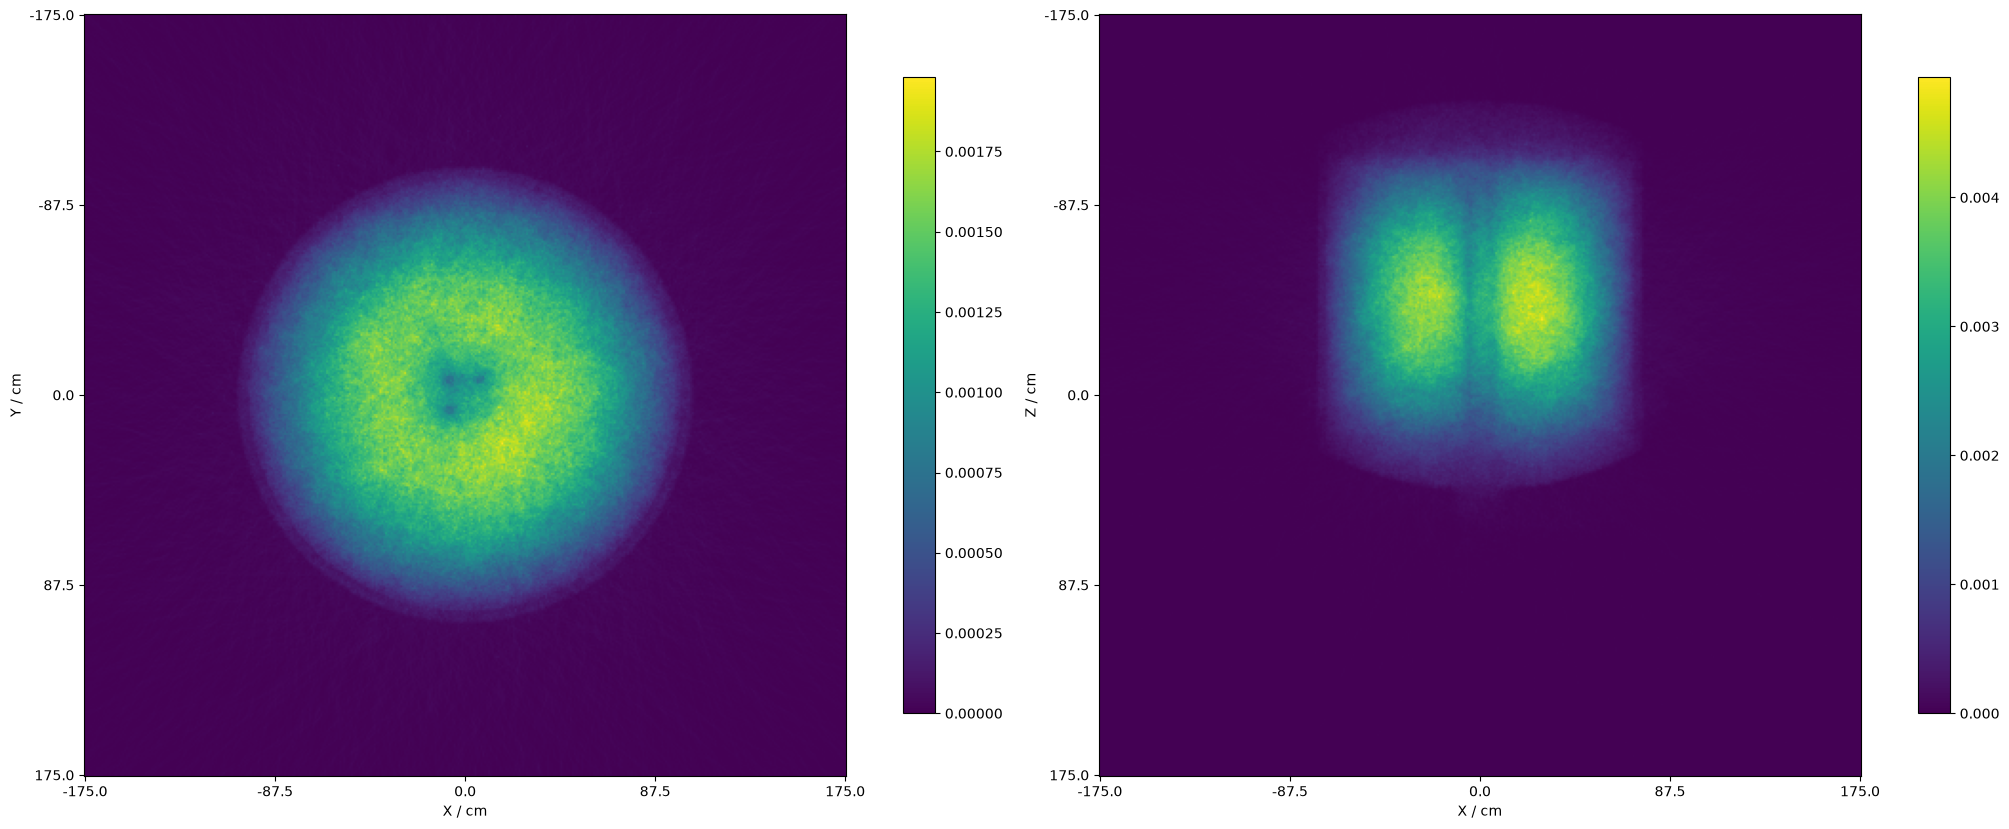

In [11]:
import matplotlib.pyplot as plt
import numpy as np
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(20,16), constrained_layout=True)

ax1.set_xticks(np.arange(0,401,399/4))
ax1.set_xticklabels(np.arange(-175,176,350./4))
ax2.set_xticks(np.arange(0,400,399/4))
ax2.set_xticklabels(np.arange(-175,176,350./4))
ax1.set_yticks(np.arange(0,400,399/4))
ax1.set_yticklabels(np.arange(-175,176,350./4))
ax2.set_yticks(np.arange(0,400,399/4))
ax2.set_yticklabels(np.arange(-175,176,350./4))
ax1.set_xlabel('X / cm')
ax1.set_ylabel('Y / cm')

ax2.set_xlabel('X / cm')
ax2.set_ylabel('Z / cm')
im1=ax1.imshow(flux1.mean)
fig.colorbar(im1,ax=ax1,shrink=0.4)
im2=ax2.imshow(flux2.mean)
fig.colorbar(im2,ax=ax2,shrink=0.4)

/tmp/ipykernel_281069/1349020123.py:6: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  fission1.mean.shape=(400,400)
/tmp/ipykernel_281069/1349020123.py:7: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  fission2.mean.shape=(400,400)


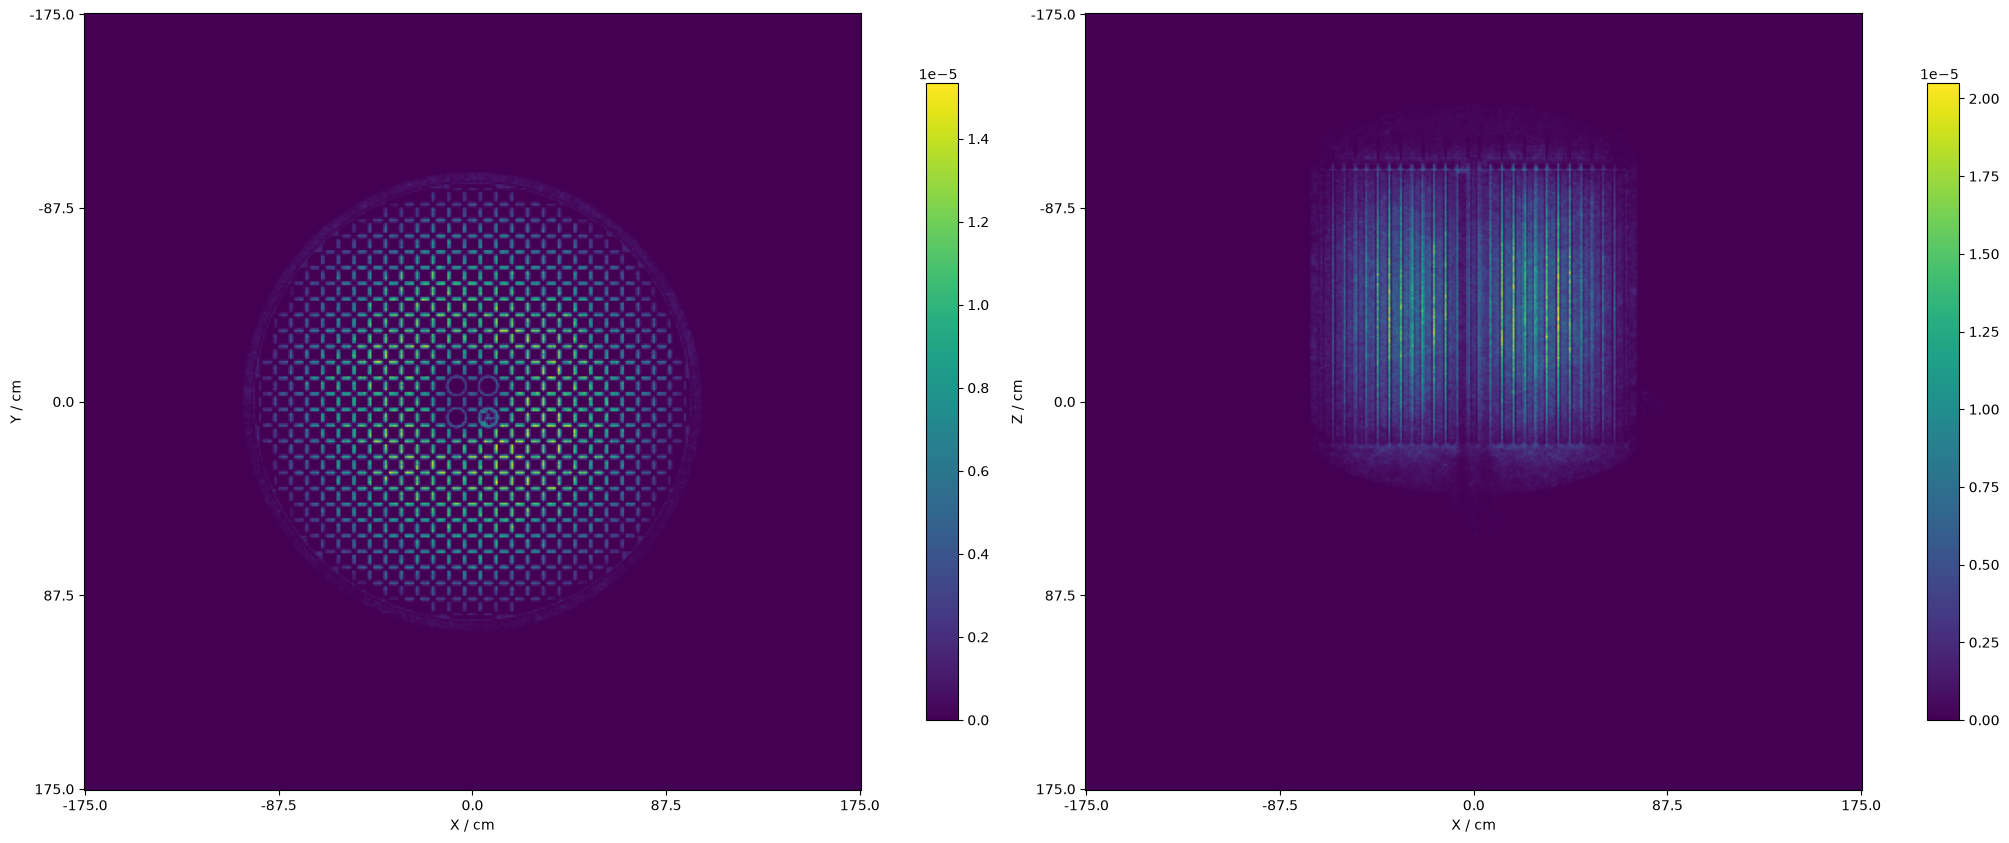

In [12]:
#Similarly we can plot fission reactions:

fission1=tl1.get_slice(scores=['fission'])
fission2=tl2.get_slice(scores=['fission'])

fission1.mean.shape=(400,400)
fission2.mean.shape=(400,400)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(20,16), constrained_layout=True)

ax1.set_xticks(np.arange(0,401,399/4))
ax1.set_xticklabels(np.arange(-175,176,350./4))
ax2.set_xticks(np.arange(0,400,399/4))
ax2.set_xticklabels(np.arange(-175,176,350./4))
ax1.set_yticks(np.arange(0,400,399/4))
ax1.set_yticklabels(np.arange(-175,176,350./4))
ax2.set_yticks(np.arange(0,400,399/4))
ax2.set_yticklabels(np.arange(-175,176,350./4))
ax1.set_xlabel('X / cm')
ax1.set_ylabel('Y / cm')

ax2.set_xlabel('X / cm')
ax2.set_ylabel('Z / cm')
im1=ax1.imshow(fission1.mean)
fig.colorbar(im1,ax=ax1,shrink=0.4)
im2=ax2.imshow(fission2.mean)
fig.colorbar(im2,ax=ax2,shrink=0.4)

In [13]:
#define a lograrithmic binning from 1keV to 10 MeV
ef=energyrange=openmc.EnergyFilter(np.logspace(3,7,200))
te = openmc.Tally(name='energy')

sf = openmc.MaterialFilter(salt)
te.filters =[ef,sf]
te.scores = ['flux','fission']

tallies.append(te)
tallies.export_to_xml()

In [14]:
os.system("rm -f summary.h5 statepoint.20.h5")
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

In [15]:
sp=openmc.StatePoint('statepoint.20.h5')

In [16]:
tl=sp.get_tally(name='energy')

e1=tl.get_slice(scores=['flux'])
e2=tl.get_slice(scores=['fission'])

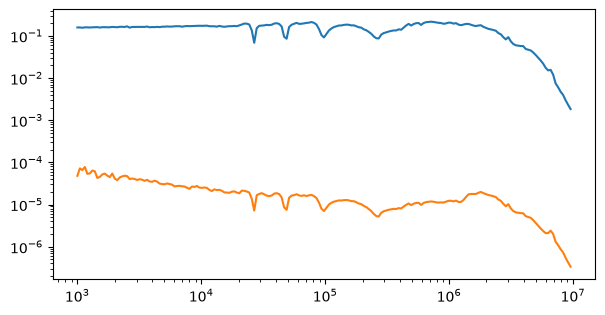

In [17]:
fig,ax=plt.subplots(figsize=(7,3.5),squeeze=True)
ax.plot(ef.values[:199],e1.mean[:,0,0])
ax.plot(ef.values[:199],e2.mean[:,0,0])
ax.set_xscale('log')
ax.set_yscale('log')

In [21]:
#geometry
os.system('rm -f materials.xml geometry.xml tallies.xml')
h5m_filepath = "/home/linz/ondemand/openmc/msre/msre_docker/msre_control_in.h5m"
dag_univ = openmc.DAGMCUniverse(h5m_filepath)
geom = openmc.Geometry(root=dag_univ)
geom.export_to_xml()

b_w_conc={'Al2O3':0.3,'Gd2O3':0.7} # Wt. (D. Shen et.al. Nucl. Sc. & Eng., v. 195, pp. 825, 2021)
A_w={'Al':26.9815385,'Gd':157.25, 'O':15.99} #g/mol, (Webelements.com)
rho={'Al2O3':3.987,'Gd2O3':7.07} # g /cc, (Wikipedia: Aluminium_oxide & Gadolinium(III)_oxide)
b_mol_w={'Al2O3':2*A_w['Al']+ 3*A_w['O'],'Gd2O3':2*A_w['Gd']+3*A_w['O']}
bush_mol_comp={'Al2O3':(b_w_conc['Al2O3']/b_mol_w['Al2O3'])/( b_w_conc['Al2O3']/b_mol_w['Al2O3'] + b_w_conc['Gd2O3']/b_mol_w['Gd2O3'] ),
                'Gd2O3':(b_w_conc['Gd2O3']/b_mol_w['Gd2O3'])/( b_w_conc['Al2O3']/b_mol_w['Al2O3'] + b_w_conc['Gd2O3']/b_mol_w['Gd2O3'] )}

bush=openmc.Material(name='bush')
bush.add_element('Al',2/5*bush_mol_comp['Al2O3'],'ao')
bush.add_element('Gd',2/5*bush_mol_comp['Gd2O3'],'ao')
bush.add_element('O',3/5*bush_mol_comp['Al2O3']+3/5*bush_mol_comp['Gd2O3'],'ao')
bush.set_density('g/cc',b_w_conc['Al2O3']*rho['Al2O3'] +b_w_conc['Gd2O3']*rho['Gd2O3'] )

t1 = openmc.Tally(name='flux1')
t1.filters =[mesh1_filter]
t1.scores = ['flux','fission','absorption']

t2 = openmc.Tally(name='flux2')
t2.filters =[mesh2_filter]
t2.scores = ['flux','fission','absorption']

tallies=openmc.Tallies([t1,t2])
tallies.export_to_xml()


materials=openmc.Materials([helium,salt,graphite,inconel,inor,bush])
materials.export_to_xml()

/opt/python/lib64/python3.12/site-packages/openmc/plots.py:1389: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


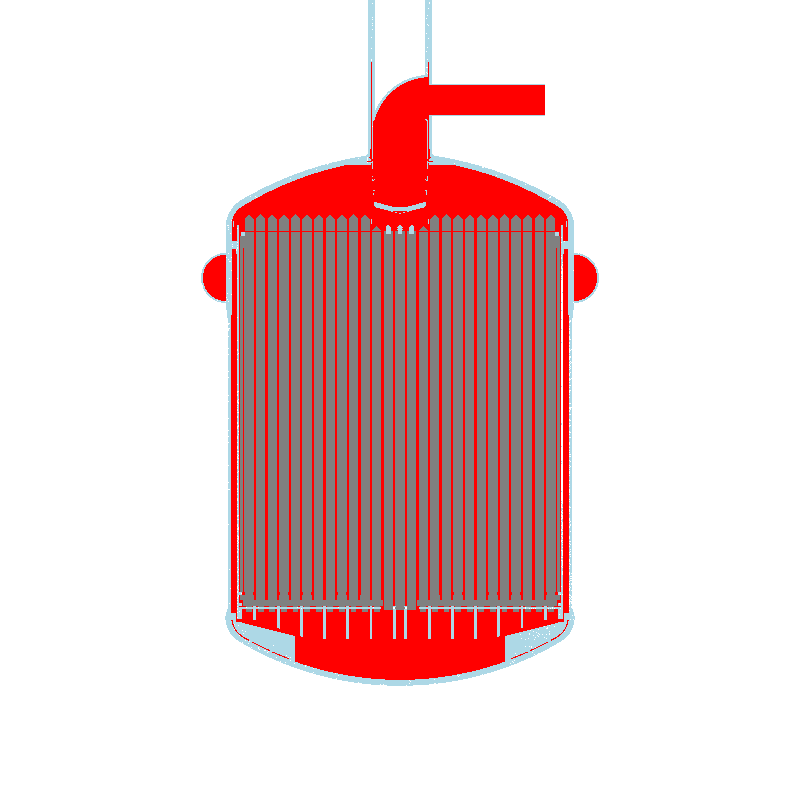

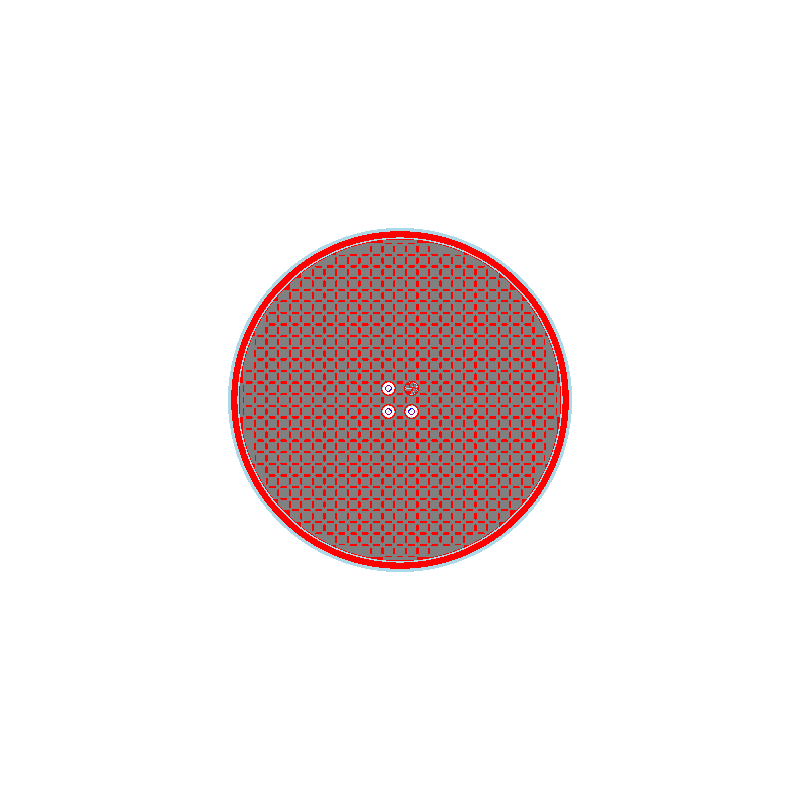

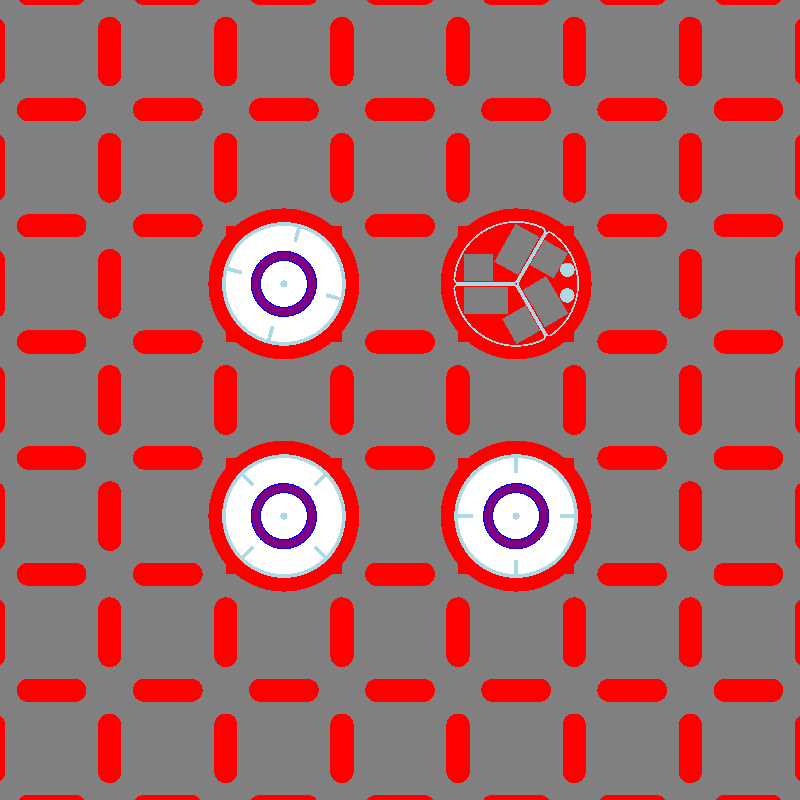

In [23]:
xwidth = 350
yheight = 350
material_colors={salt:'red', inor:'lightblue', inconel:'blue',helium:'white',graphite:'gray',bush:'purple'}
#xz plot
p1 = openmc.Plot()
p1.background='white'
p1.basis = 'xz'
p1.width = (xwidth,yheight)
p1.origin=(0,0,125)
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors=material_colors
#xy plot
p2 = openmc.Plot()
p2.background='white'
p2.basis='xy'
p2.width=(xwidth, yheight)
p2.pixels = (800,800)
p2.origin=(0,0,100)
p2.color_by='material'
p2.colors=material_colors

p3 = openmc.Plot()
p3.background='white'
p3.basis='xy'
p3.width=(xwidth/10, yheight/10)
p3.pixels = (800,800)
p3.origin=(0,0,100)
p3.color_by='material'
p3.colors=material_colors

plots=openmc.Plots([p1,p2,p3])
openmc.plot_inline(plots)

/opt/python/lib64/python3.12/site-packages/openmc/plots.py:1389: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


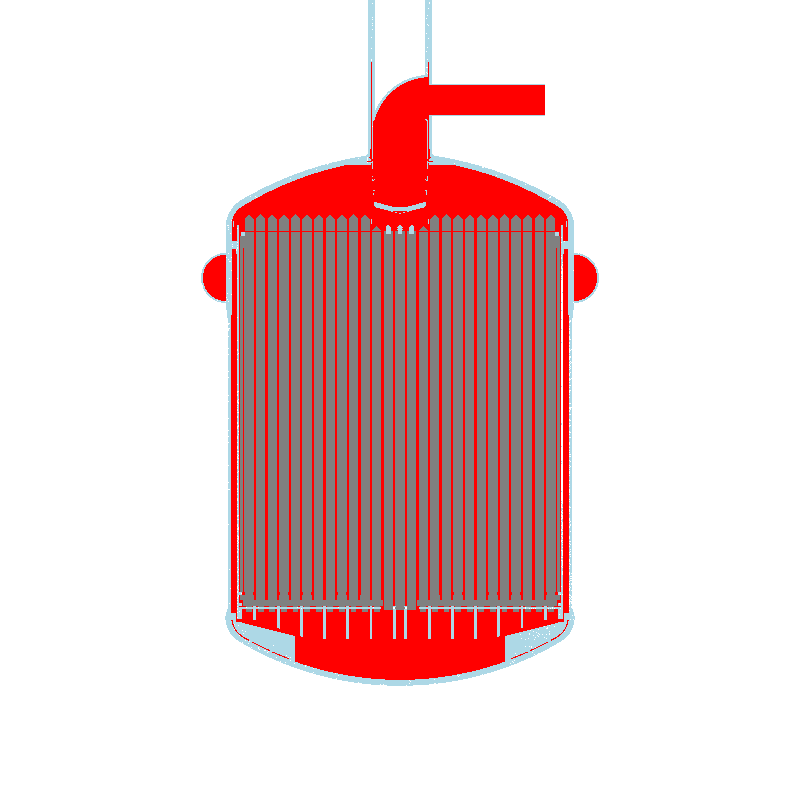

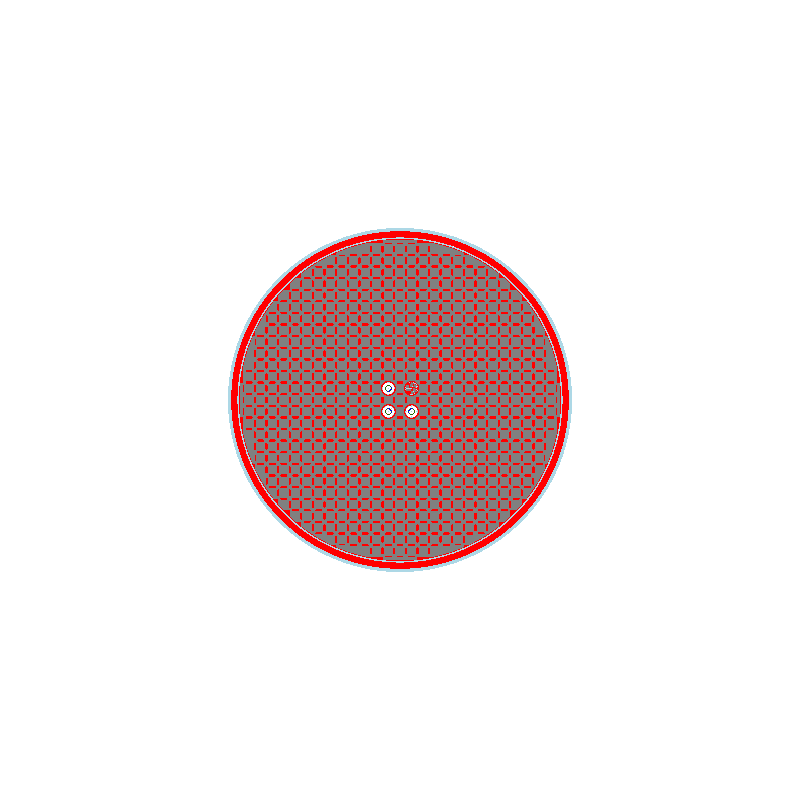

In [25]:
xwidth = 350
yheight = 350
material_colors={salt:'red', inor:'lightblue', inconel:'blue',helium:'white',graphite:'gray'}
#xz plot
p1 = openmc.Plot()
p1.background='white'
p1.basis = 'xz'
p1.width = (xwidth,yheight)
p1.origin=(0,0,125)
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors=material_colors
#xy plot
p2 = openmc.Plot()
p2.background='white'
p2.basis='xy'
p2.width=(xwidth, yheight)
p2.pixels = (800,800)
p2.origin=(0,0,100)
p2.color_by='material'
p2.colors=material_colors

plots=openmc.Plots([p1,p2])
openmc.plot_inline(plots)

In [24]:
#currently running
os.system("rm -f summary.h5 statepoint.20.h5")
openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

/tmp/ipykernel_281069/2132534055.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  abs1.mean.shape=(400,400)
/tmp/ipykernel_281069/2132534055.py:11: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  abs2.mean.shape=(400,400)


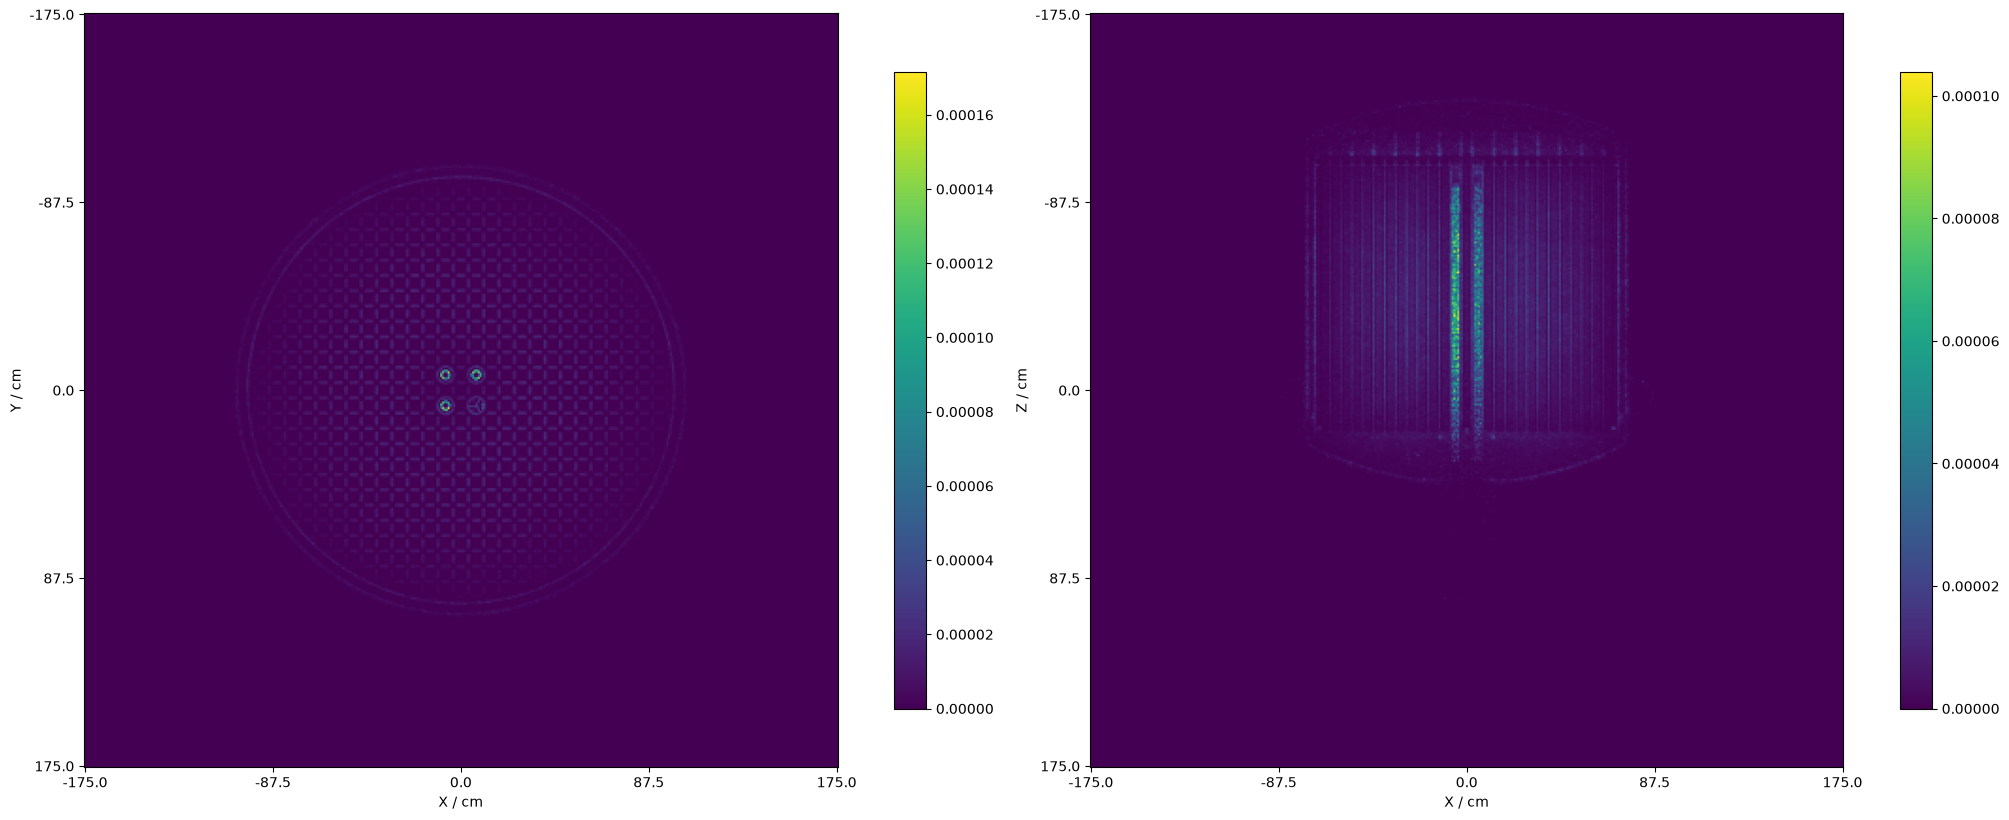

In [26]:
#Plot maps of the absorption
sp=openmc.StatePoint('statepoint.20.h5')

tl1=sp.get_tally(name='flux1')
tl2=sp.get_tally(name='flux2')

abs1=tl1.get_slice(scores=['absorption'])
abs2=tl2.get_slice(scores=['absorption'])

abs1.mean.shape=(400,400)
abs2.mean.shape=(400,400)

fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(20,16), constrained_layout=True)

ax1.set_xticks(np.arange(0,401,399/4))
ax1.set_xticklabels(np.arange(-175,176,350./4))
ax2.set_xticks(np.arange(0,400,399/4))
ax2.set_xticklabels(np.arange(-175,176,350./4))
ax1.set_yticks(np.arange(0,400,399/4))
ax1.set_yticklabels(np.arange(-175,176,350./4))
ax2.set_yticks(np.arange(0,400,399/4))
ax2.set_yticklabels(np.arange(-175,176,350./4))
ax1.set_xlabel('X / cm')
ax1.set_ylabel('Y / cm')

ax2.set_xlabel('X / cm')
ax2.set_ylabel('Z / cm')
im1=ax1.imshow(abs1.mean)
fig.colorbar(im1,ax=ax1,shrink=0.4)
im2=ax2.imshow(abs2.mean)
fig.colorbar(im2,ax=ax2,shrink=0.4)

In [7]:
#Finally we build a settings object for OpenMC where we define parameters for the run.
#dont use this
settings = openmc.Settings()
settings.source = source
settings.batches = 20
#needs to raise to 200
settings.inactive = 5
#needs to raise to 20
settings.particles = 20000
#needs to raise to 100000
settings.source_rejection_fraction = 0.01
#lower the rejection fraction
settings.export_to_xml()

openmc.run()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

RuntimeError: Material with name/ID 'inor-8' not found for volume (cell) 3 -------------------------------------------------------------------------- MPI_ABORT was invoked on rank 0 in communicator MPI_COMM_WORLD Proc: [[34776,0],0] Errorcode: -1 NOTE: invoking MPI_ABORT causes Open MPI to kill all MPI processes. You may or may not see output from other processes, depending on exactly when Open MPI kills them. --------------------------------------------------------------------------

In [9]:
print("Python thinks H5M is:")
print(h5m_filepath)

print("\nDAGMC material names:")
print(dag_univ.material_names)

print("\nOpenMC material names:")
for mat in materials:
    print(mat.name)

Python thinks H5M is:
../h5m/msre_full.h5m

DAGMC material names:
['concrete', 'graphite', 'inor-8', 'insulation', 'salt', 'steel', 'steelwater', 'watersand']

OpenMC material names:
helium
salt
graphite
inconel
inor
